# Hypothesis Testing — Worked Examples

This notebook walks through the hypothesis tests documented in `README.md` using the modules in this repo.

Sections:
1. Z-test (critical value & p-value methods)
2. T-test (one-sample, two-sample, paired)
3. Chi-square (goodness-of-fit, independence)
4. ANOVA / F-test
5. Effect size & power analysis

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from z_test import ZTest
from t_test import TTest
from chi_square_test import ChiSquareTest
from anova_f_test import AnovaFTest
from effect_size_power import EffectSize, PowerAnalysis

np.random.seed(42)

## 1. Z-Test

Claim: Amazon sales in July 2025 = $10B. Sample mean = $9B, σ = 2, n = 40, α = 0.05.

In [17]:
z_test = ZTest(alpha=0.05, tail='two')
result = z_test.one_sample(sample_mean=9, pop_mean=10, pop_std=2, n=40)

for k, v in result.items():
    print(f"{k:>20}: {v}")

             z_score: -3.162277660168379
             p_value: 0.0015654022580025018
                 lcv: 9.380204967695438
                 ucv: 10.619795032304562
      standard_error: 0.31622776601683794
         reject_null: True


The sample mean (9) lies below the LCV (~9.38), so we **reject H₀**.

## 2. T-Test

### 2a. One-sample
Claim: average delivery time = 30 min. Sample of 25 deliveries with x̄ = 32, s = 4.

In [18]:
delivery_times = np.random.normal(loc=32, scale=4, size=25)
t_test = TTest(alpha=0.05, tail='two')
result = t_test.one_sample(delivery_times, pop_mean=30)

for k, v in result.items():
    print(f"{k:>20}: {v}")

         t_statistic: 1.7588775647679278
                  df: 24
             p_value: 0.09134400198014747
          t_critical: 2.063898561628024
      standard_error: 0.7652424434359235
         reject_null: False


### 2b. Two-sample independent
Compare model A and model B accuracy across 30 evaluation runs each.

In [19]:
model_a_scores = np.random.normal(loc=0.82, scale=0.03, size=30)
model_b_scores = np.random.normal(loc=0.85, scale=0.03, size=30)

result = t_test.two_sample_independent(model_a_scores, model_b_scores, equal_var=True)
for k, v in result.items():
    print(f"{k:>20}: {v}")

         t_statistic: -5.002490171592042
                  df: 58
             p_value: 5.567989536992002e-06
          t_critical: 2.0017174841452356
      standard_error: 0.007402620608082429
         reject_null: True


### 2c. Paired
Same 20 students measured before and after a training program.

In [20]:
before = np.random.normal(loc=70, scale=5, size=20)
after = before + np.random.normal(loc=3, scale=2, size=20)

result = t_test.paired(before, after)
for k, v in result.items():
    print(f"{k:>20}: {v}")

         t_statistic: 7.223969520578596
                  df: 19
             p_value: 7.369566648041115e-07
          t_critical: 2.0930240544083087
      standard_error: 0.4775228277312904
         reject_null: True


## 3. Chi-Square Test

### 3a. Goodness-of-fit
100 coin flips → 60 heads, 40 tails. Is the coin fair?

In [21]:
chi = ChiSquareTest(alpha=0.05)
result = chi.goodness_of_fit(observed=[60, 40], expected=[50, 50])

for k, v in result.items():
    print(f"{k:>20}: {v}")

      chi2_statistic: 4.0
                  df: 1
             p_value: 0.04550026389635842
       chi2_critical: 3.8414588206941205
         reject_null: True


### 3b. Independence
Test whether device type and purchase decision are independent.

In [22]:
contingency = pd.DataFrame(
    [[120, 80], [60, 140]],
    index=['Mobile', 'Desktop'],
    columns=['Purchased', 'Did Not Purchase'],
)
print(contingency, '\n')

result = chi.independence(contingency.values)
for k, v in result.items():
    print(f"{k:>22}: {v}")

         Purchased  Did Not Purchase
Mobile         120                80
Desktop         60               140 

        chi2_statistic: 36.36363636363636
                    df: 1
               p_value: 1.6372964095623388e-09
         chi2_critical: 3.8414588206941205
  expected_frequencies: [[ 90. 110.]
 [ 90. 110.]]
           reject_null: True


## 4. ANOVA / F-test

### 4a. One-way ANOVA
Three training algorithms — do their mean accuracies differ?

In [23]:
alg_1 = np.random.normal(0.80, 0.02, 25)
alg_2 = np.random.normal(0.83, 0.02, 25)
alg_3 = np.random.normal(0.81, 0.02, 25)

anova = AnovaFTest(alpha=0.05)
result = anova.one_way(alg_1, alg_2, alg_3)

for k, v in result.items():
    print(f"{k:>15}: {v}")

    f_statistic: 22.90715684016757
     df_between: 2
      df_within: 72
     ss_between: 0.0161550259252934
      ss_within: 0.025388612710363235
     ms_between: 0.0080775129626467
      ms_within: 0.00035261962097726715
        p_value: 1.9991242883321547e-08
     f_critical: 3.123907448545777
    reject_null: True


### 4b. Variance ratio (F-test for equality of variances)

In [24]:
sample1 = np.random.normal(50, 5, 30)
sample2 = np.random.normal(50, 8, 30)

result = anova.variance_ratio(sample1, sample2)
for k, v in result.items():
    print(f"{k:>15}: {v}")

    f_statistic: 2.067051587727458
            df1: 29
            df2: 29
        p_value: 0.05512803785110609
     f_critical: 2.1009958172842116
    reject_null: False


## 5. Effect Size & Power Analysis

In [25]:
es = EffectSize()
d = es.cohens_d_two_sample(model_a_scores, model_b_scores)
print(f"Cohen's d: {d:.3f} ({es.interpret_cohens_d(d)})")

v = es.cramers_v(contingency.values)
print(f"Cramer's V (device vs purchase): {v:.3f}")

Cohen's d: -1.292 (large)
Cramer's V (device vs purchase): 0.302


In [26]:
power = PowerAnalysis(alpha=0.05)

print(f"Power at n=30, d=0.5: {power.power_two_sample(0.5, n1=30):.3f}")
print(f"Sample size needed for d=0.5 at 80% power: {power.sample_size_two_sample(0.5):.1f}")
print(f"Minimum detectable effect at n=50, 80% power: {power.minimum_detectable_effect(50):.3f}")

Power at n=30, d=0.5: 0.478
Sample size needed for d=0.5 at 80% power: 63.8
Minimum detectable effect at n=50, 80% power: 0.404


### Power curve — sample size vs power for varying effect sizes

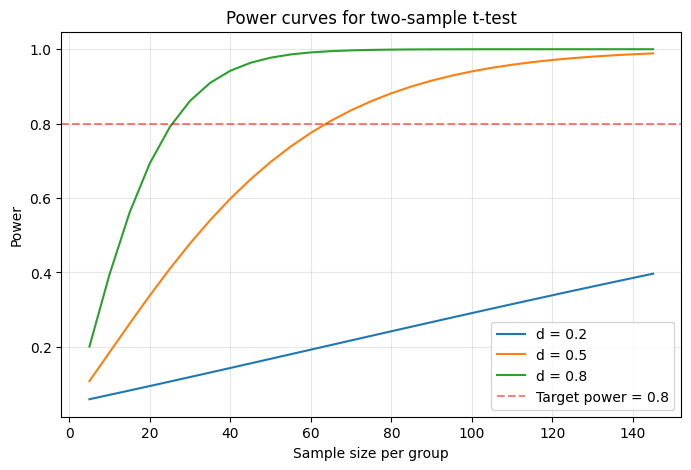

In [27]:
sample_sizes = np.arange(5, 150, 5)
effect_sizes = [0.2, 0.5, 0.8]

plt.figure(figsize=(8, 5))
for d in effect_sizes:
    powers = [power.power_two_sample(d, n1=n) for n in sample_sizes]
    plt.plot(sample_sizes, powers, label=f'd = {d}')

plt.axhline(0.8, color='red', linestyle='--', alpha=0.5, label='Target power = 0.8')
plt.xlabel('Sample size per group')
plt.ylabel('Power')
plt.title('Power curves for two-sample t-test')
plt.legend()
plt.grid(alpha=0.3)
plt.show()